Model evaluation metrics: classification metrics on an imbalanced breast-cancer-style problem (why accuracy alone is misleading), and regression metrics on the diabetes dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score,
)

data = load_breast_cancer()
X, y = data.data, data.target
print("Class balance:", np.bincount(y), "(0=malignant, 1=benign)")

Class balance: [212 357] (0=malignant, 1=benign)


In [2]:
# Make it artificially imbalanced to show why accuracy alone is a bad metric
rng = np.random.RandomState(42)
minority_idx = np.where(y == 0)[0]
keep_minority = rng.choice(minority_idx, size=20, replace=False)
majority_idx = np.where(y == 1)[0]
imbalanced_idx = np.concatenate([keep_minority, majority_idx])
rng.shuffle(imbalanced_idx)

X_imb, y_imb = X[imbalanced_idx], y[imbalanced_idx]
print("Imbalanced class counts:", np.bincount(y_imb))
print(f"Majority class baseline accuracy (always predict 1): {(y_imb == 1).mean()*100:.2f}%")

Imbalanced class counts: [ 20 357]
Majority class baseline accuracy (always predict 1): 94.69%


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=5000, class_weight=None)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}  (of predicted positives, how many were right)")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}  (of actual positives, how many did we catch)")
print(f"F1:        {f1_score(y_test, y_pred):.4f}  (harmonic mean of precision & recall)")
print(f"\nA model that always predicts the majority class would score {(y_test==1).mean():.4f} accuracy")
print("-- comparable to our trained model's accuracy, which is why accuracy alone is misleading on imbalanced data.")

Accuracy:  1.0000
Precision: 1.0000  (of predicted positives, how many were right)
Recall:    1.0000  (of actual positives, how many did we catch)
F1:        1.0000  (harmonic mean of precision & recall)

A model that always predicts the majority class would score 0.9474 accuracy
-- comparable to our trained model's accuracy, which is why accuracy alone is misleading on imbalanced data.


In [4]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]}  False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}  True Positives:  {cm[1,1]}")
print("\n", classification_report(y_test, y_pred, target_names=data.target_names))

Confusion Matrix:
[[  6   0]
 [  0 108]]

True Negatives:  6  False Positives: 0
False Negatives: 0  True Positives:  108

               precision    recall  f1-score   support

   malignant       1.00      1.00      1.00         6
      benign       1.00      1.00      1.00       108

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



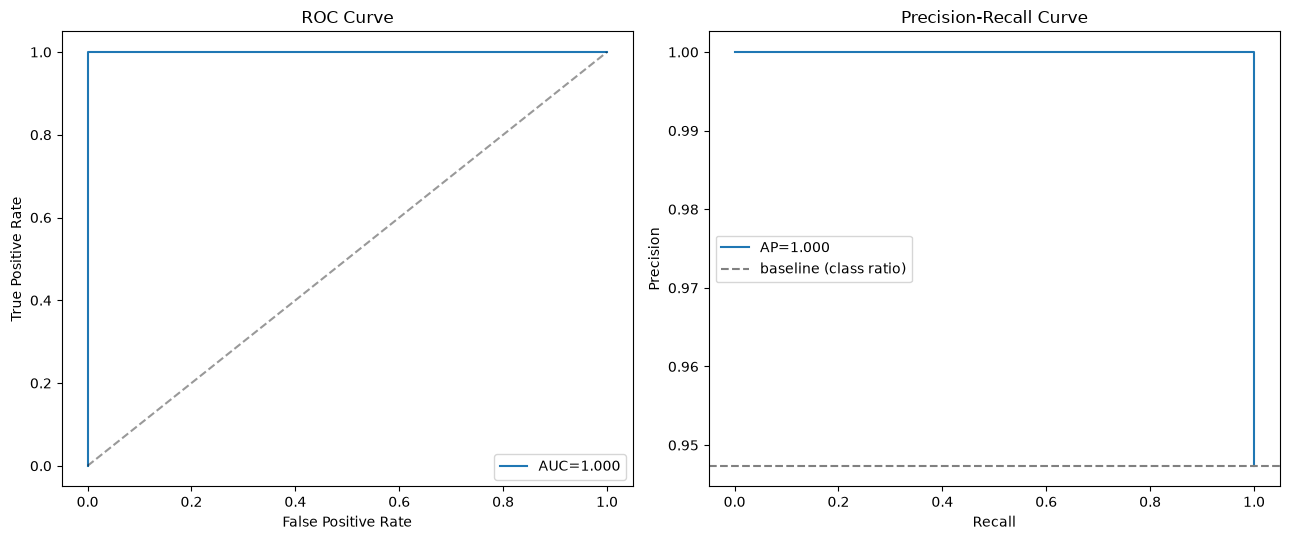

ROC-AUC can look deceptively good under heavy imbalance since it includes True Negatives (easy to get right).
PR-AUC focuses entirely on the positive class and is the more honest metric here.


In [5]:
# ROC curve and Precision-Recall curve -- PR curve is more informative under class imbalance
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, y_proba):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall_vals, precision_vals, label=f'AP={average_precision_score(y_test, y_proba):.3f}')
axes[1].axhline((y_test==1).mean(), color='gray', linestyle='--', label='baseline (class ratio)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
plt.tight_layout()
plt.show()
print("ROC-AUC can look deceptively good under heavy imbalance since it includes True Negatives (easy to get right).")
print("PR-AUC focuses entirely on the positive class and is the more honest metric here.")

In [6]:
# Regression metrics on the diabetes dataset
diabetes = load_diabetes()
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.3, random_state=42)

reg = LinearRegression()
reg.fit(Xd_train, yd_train)
yd_pred = reg.predict(Xd_test)

mae = mean_absolute_error(yd_test, yd_pred)
mse = mean_squared_error(yd_test, yd_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yd_test, yd_pred)

print(f"MAE:  {mae:.2f}  (average absolute error, same units as target, robust to outliers)")
print(f"MSE:  {mse:.2f}  (penalizes large errors more -- squared)")
print(f"RMSE: {rmse:.2f}  (back in original units, still penalizes large errors more than MAE)")
print(f"R^2:  {r2:.4f}  (fraction of variance explained, 1.0=perfect, 0=no better than predicting the mean)")

MAE:  41.92  (average absolute error, same units as target, robust to outliers)
MSE:  2821.75  (penalizes large errors more -- squared)
RMSE: 53.12  (back in original units, still penalizes large errors more than MAE)
R^2:  0.4773  (fraction of variance explained, 1.0=perfect, 0=no better than predicting the mean)


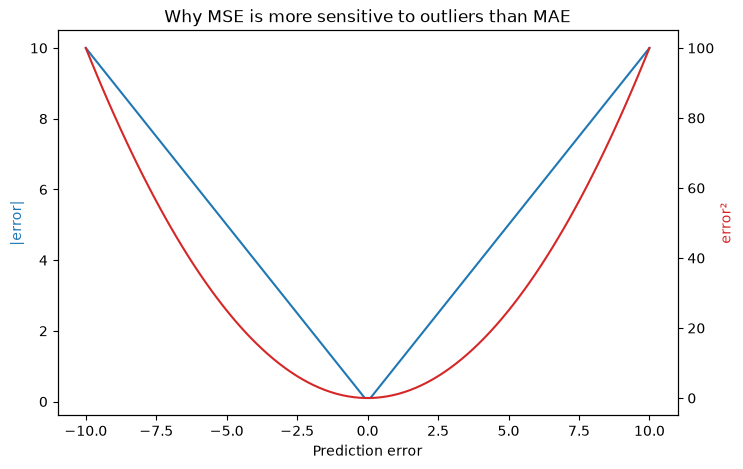

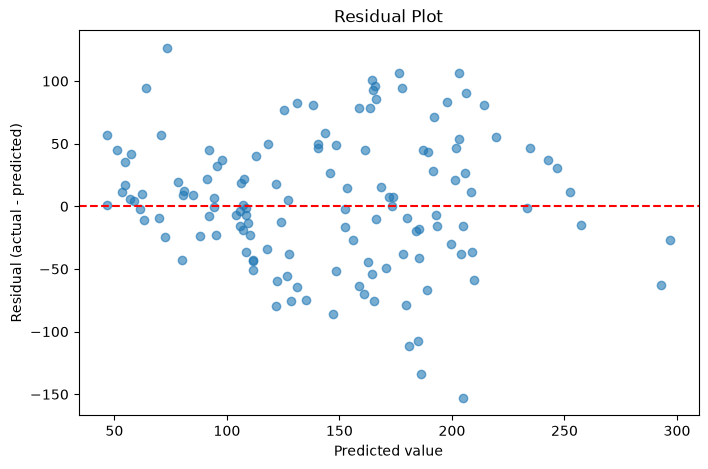

In [7]:
# Visualize why MSE/RMSE punishes large errors harder than MAE
errors = np.linspace(-10, 10, 100)
mae_curve = np.abs(errors)
mse_curve = errors ** 2

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(errors, mae_curve, label='|error| (MAE contribution)', color='tab:blue')
ax1.set_xlabel('Prediction error')
ax1.set_ylabel('|error|', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(errors, mse_curve, label='error² (MSE contribution)', color='tab:red')
ax2.set_ylabel('error²', color='tab:red')
plt.title('Why MSE is more sensitive to outliers than MAE')
plt.show()

# Residual plot
plt.figure(figsize=(8, 5))
residuals = yd_test - yd_pred
plt.scatter(yd_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted value')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual Plot')
plt.show()